# Importar librerias

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-dark')

# Importar datasets de origen

In [2]:
servicios = pd.read_csv('servicios.csv')
proveedores = pd.read_csv('proveedores.csv')
clientes = pd.read_csv('clientes.csv')
calendario = pd.read_csv('calendario.csv')

# Validación de datos a los 4 dataframes se les realizo el mismo proceso

In [3]:
servicios.head()

,servicio_id,fecha_servicio,tipo_servicio,ciudad,cliente,proveedor_id,tiempo_respuesta_min,estado_servicio,costo_servicio
0,SRV012291,2024-03-28 03:28:00,Grúa,Bogotá,Mundial Seguros,3,82.0,Completado,335766
1,SRV013946,2024-06-09 20:45:00,Batería,Bogotá,Banco Davivienda,14,15.0,Completado,151191
2,SRV014899,2024-03-01 23:36:00,Grúa,Barranquilla,Mundial Seguros,146,66.0,Completado,368466
3,SRV010130,2024-02-23 23:49:00,Grúa,Medellín,Liberty Seguros,93,67.0,Completado,289845
4,SRV005568,2024-02-23 00:50:00,Grúa,Bogotá,Avianca,9,65.0,Completado,202441


In [4]:
# Información general del dataframe

servicios.info()

<class 'pandas.DataFrame'>
RangeIndex: 15300 entries, 0 to 15299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   servicio_id           15300 non-null  str    
 1   fecha_servicio        15300 non-null  str    
 2   tipo_servicio         15300 non-null  str    
 3   ciudad                15300 non-null  str    
 4   cliente               15300 non-null  str    
 5   proveedor_id          15300 non-null  int64  
 6   tiempo_respuesta_min  13928 non-null  float64
 7   estado_servicio       15300 non-null  str    
 8   costo_servicio        15300 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 1.1 MB


In [5]:
# Validación de valores nulos en el dataframe

servicios.isnull().sum()

servicio_id                0
fecha_servicio             0
tipo_servicio              0
ciudad                     0
cliente                    0
proveedor_id               0
tiempo_respuesta_min    1372
estado_servicio            0
costo_servicio             0
dtype: int64

In [6]:
# Cantidad de registros repetivos

print(f'La cantidad de registros repetidos es: {servicios.duplicated().sum()}')

La cantidad de registros repetidos es: 285


In [7]:
# Estadistica descriptiva de las columnas dataframe

np.round(servicios.describe(),0)

,proveedor_id,tiempo_respuesta_min,costo_servicio
count,15300.0,13928.0,15300.0
mean,74.0,44.0,192094.0
std,43.0,24.0,86957.0
min,1.0,-20.0,50000.0
25%,38.0,25.0,114123.0
50%,75.0,39.0,188002.0
75%,111.0,62.0,261816.0
max,150.0,147.0,540071.0


In [8]:
# Validación de valores unicos por columnas

servicios.ciudad.unique()

<StringArray>
[      'Bogotá', 'Barranquilla',     'Medellín',         'Cali',
       'BOGOTA',  'Bogota D.C.',      ' Bogotá']
Length: 7, dtype: str

<Axes: >

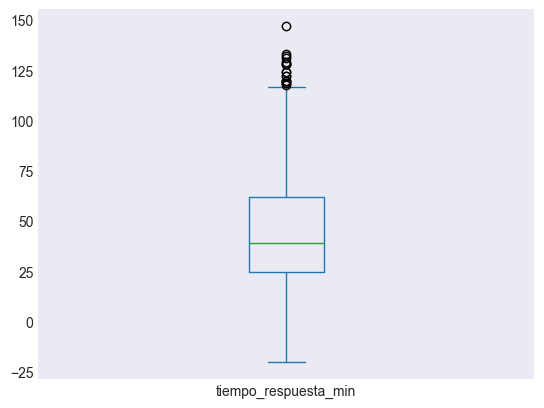

In [9]:
# representación visual de outliers

servicios.tiempo_respuesta_min.plot(kind='box')

# Limpieza de Datos

* Tratamiento de outliers negativos
* Formateo de fechas de STR a datetime
* Eliminar registros duplicados
* Manejo de valores NULL
* Homologación de categorias

In [10]:
# Copia de dataframe originales

servicios_limpio = servicios.copy()
calendario_limpio = calendario.copy()

In [11]:

servicios_limpio = servicios_limpio.query('tiempo_respuesta_min > 0') # Tratamiento de Outlierns negativos

servicios_limpio['fecha_servicio'] = pd.to_datetime(servicios_limpio['fecha_servicio']).dt.date # Formatear la fecha de str a datetime

servicios_limpio = servicios_limpio.drop_duplicates() # Borrar valores duplicados

servicios_limpio['tiempo_respuesta_min'] = servicios_limpio['tiempo_respuesta_min'].fillna(servicios_limpio['tiempo_respuesta_min'].mean()) # Llenando los valores nulos con un promedio de tiempos de respuesta

servicios_limpio['ciudad'] = servicios_limpio['ciudad'].map({' Bogotá':'Bogotá',
                                                'BOGOTA':'Bogotá',
                                                'Bogota D.C.':'Bogotá',
                                                'Bogotá':'Bogotá',
                                                'Barranquilla':'Barranquilla',
                                                'Medellín':'Medellín',
                                                'Cali':'Cali'}) # Homologación de ciudades

calendario_limpio['fecha'] = pd.to_datetime(calendario_limpio['fecha']).dt.date # Formatear la fecha de str a datetime


In [ ]:
# Dataframes limpios para realizar inserción en la base de datos y realizar las consultas

servicios_limpio.to_csv('servicios_limpio.csv', index=False, encoding='utf-8')
calendario_limpio.to_csv('calendario_limpio.csv', index=False, encoding='utf-8')
proveedores.to_csv('proveedores_limpio.csv', index=False, encoding='utf-8')
clientes.to_csv('clientes_limpio.csv', index=False, encoding='utf-8')
    

# Series de tiempo y Modelo

In [14]:
df_servicios = servicios_limpio.groupby('fecha_servicio')['servicio_id'].count().reset_index()
df_servicios.columns = ['fecha_servicio', 'total_servicios']
df_servicios['fecha_servicio'] = pd.to_datetime(df_servicios['fecha_servicio'])

df_servicios = df_servicios.set_index('fecha_servicio')

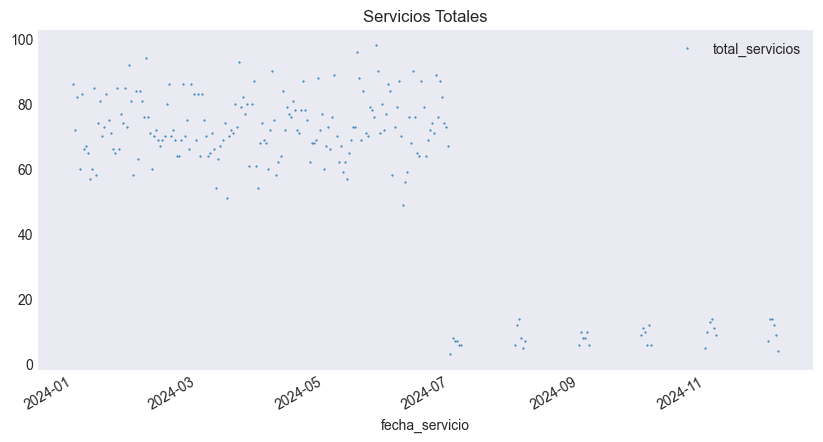

In [15]:
# Visualización grafica de todos los servicios realizados

color_pal = sns.color_palette()

df_servicios.plot(style='.',
                       figsize=(10,5),
                       ms=1,
                       color = color_pal[0],
                       title="Servicios Totales")

plt.show()


<Figure size 640x480 with 0 Axes>

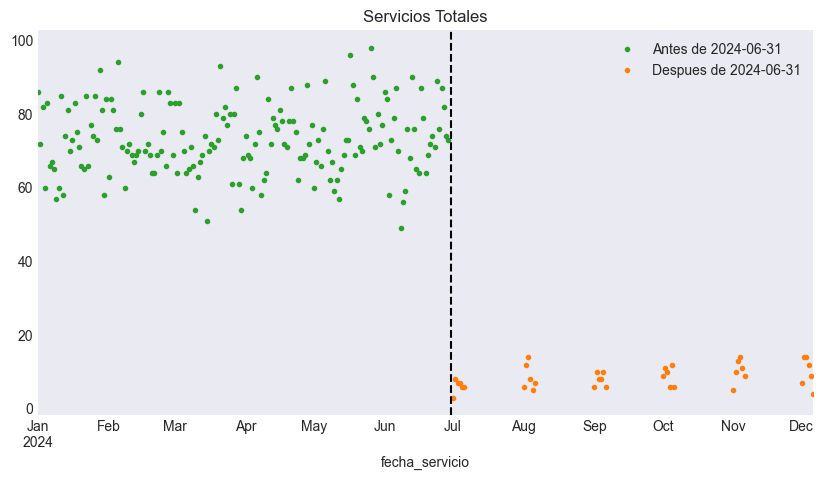

In [16]:
# Validación de cambios en la serie

plt.figure()
fig, ax = plt.subplots(figsize=(10,5))

df_servicios.query("index < '2024-06-30'").plot(ax=ax, style='.',
                                                color=color_pal[2],
                                                title="Servicios Totales")
df_servicios.query("index > '2024-06-30'").plot(ax=ax, style='.',
                                                color=color_pal[1],
                                                title="Servicios Totales")
ax.axvline('2024-06-30', color='black', ls='--')
ax.legend(['Antes de 2024-06-31','Despues de 2024-06-31'])

plt.show()


In [17]:
from pandas.api.types import CategoricalDtype

cat_tipos = CategoricalDtype(categories=['Monday','Tuesday',
                                         'Wednesday',
                                         'Thursday','Friday',
                                         'Saturday','Sunday'], ordered=True)

def creacion_caracteristicas(df_servicios, label=None):
    
    #Creacion de caracteristicas de la serie de tiempo basado en el indec
    
    df = df_servicios.copy()
    df['date'] = df.index
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_tipos)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year 
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    
    X = df[['dayofweek','quarter','month','year',
            'dayofyear','dayofmonth','weekday']]
    
    if label:
        y = df[label]
        return X, y
    return X 

X, y = creacion_caracteristicas(df_servicios, label='total_servicios' )
features_and_target = pd.concat([X,y], axis=1)   

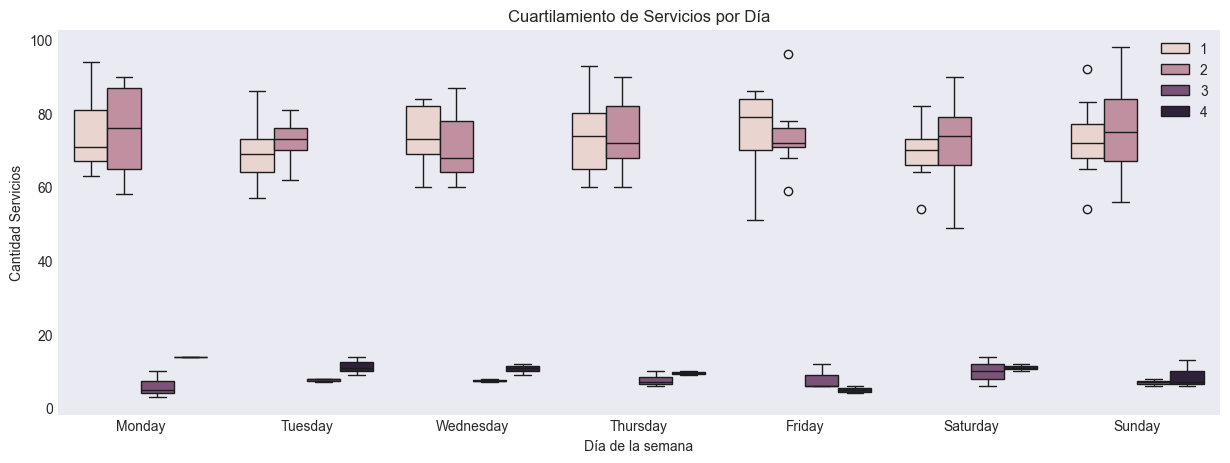

In [18]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot(data=features_and_target.dropna(),
            x='weekday',
            y='total_servicios',
            hue='quarter',
            ax=ax,
            linewidth=1)
ax.set_title('Cuartilamiento de Servicios por Día')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Cantidad Servicios')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

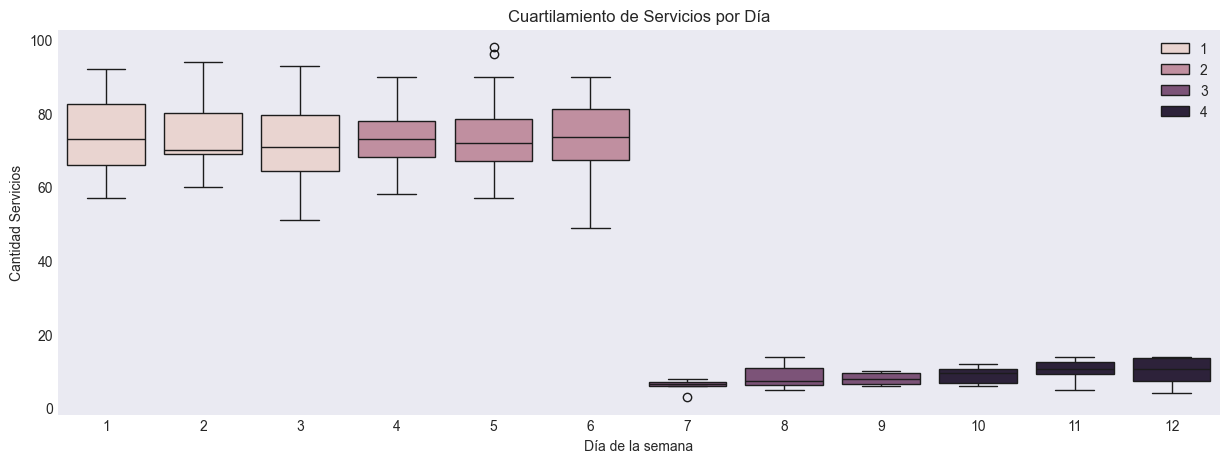

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot(data=features_and_target.dropna(),
            x='month',
            y='total_servicios',
            hue='quarter',
            ax=ax,
            linewidth=1)
ax.set_title('Cuartilamiento de Servicios por Mes')
ax.set_xlabel('Meses')
ax.set_ylabel('Cantidad Servicios')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

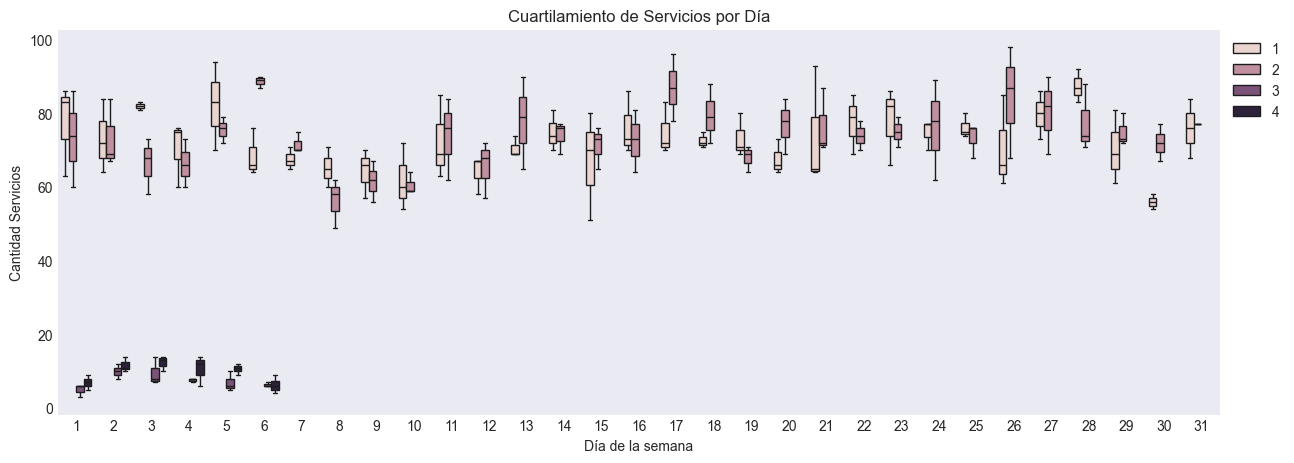

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
sns.boxplot(data=features_and_target.dropna(),
            x='dayofmonth',
            y='total_servicios',
            hue='quarter',
            ax=ax,
            linewidth=1)
ax.set_title('Cuartilamiento de Servicios por los días del mes')
ax.set_xlabel('Días del mes')
ax.set_ylabel('Cantidad Servicios')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

## Train/Test Split

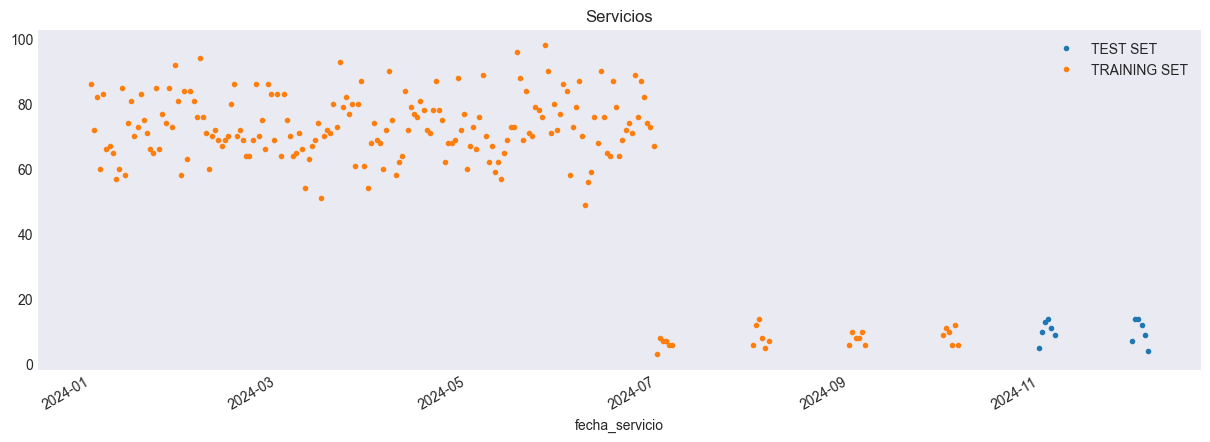

In [ ]:
dia_division = '2024-05-30'

train_serv = df_servicios.loc[df_servicios.index <= dia_division].copy()
test_serv = df_servicios.loc[df_servicios.index > dia_division].copy()

# Graficar train y test para visualizar lo que dividimos

test_serv\
        .rename(columns= {'total_servicios': 'TEST SET'})\
        .join(train_serv.rename(columns={'total_servicios':'TRAINING SET'}),
              how = 'outer') \
        .plot(figsize=(15,5), title ='Servicios', style='.')
plt.show()

## Prophet Model

In [71]:
train_prophet = train_serv.reset_index()\
    .rename(columns={'fecha_servicio':'ds', 'total_servicios':'y'})

In [72]:
%%time

model = Prophet(changepoint_prior_scale=0.5,
                seasonality_prior_scale=10.0,
                seasonality_mode='multiplicative')
model.fit(train_prophet)

12:14:39 - cmdstanpy - INFO - Chain [1] start processing
12:14:39 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 78.1 ms
Wall time: 243 ms


In [74]:
test_prophet = test_serv.reset_index()\
    .rename(columns={'fecha_servicio':'ds', 'total_servicios':'y'})
    
serv_test_fcst = model.predict(test_prophet)

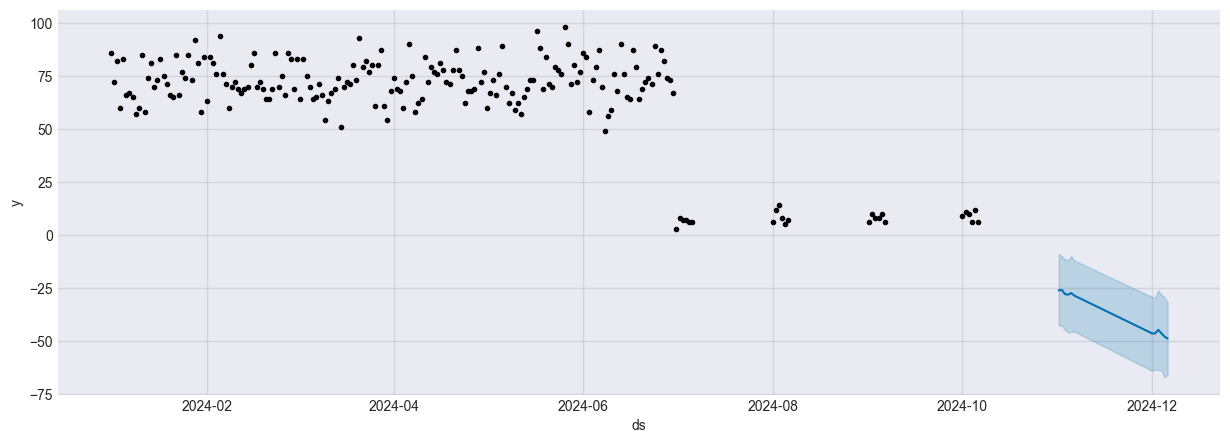

In [75]:
fig, ax = plt.subplots(figsize=(15,5))
fig = model.plot(serv_test_fcst, ax=ax)
plt.show()  

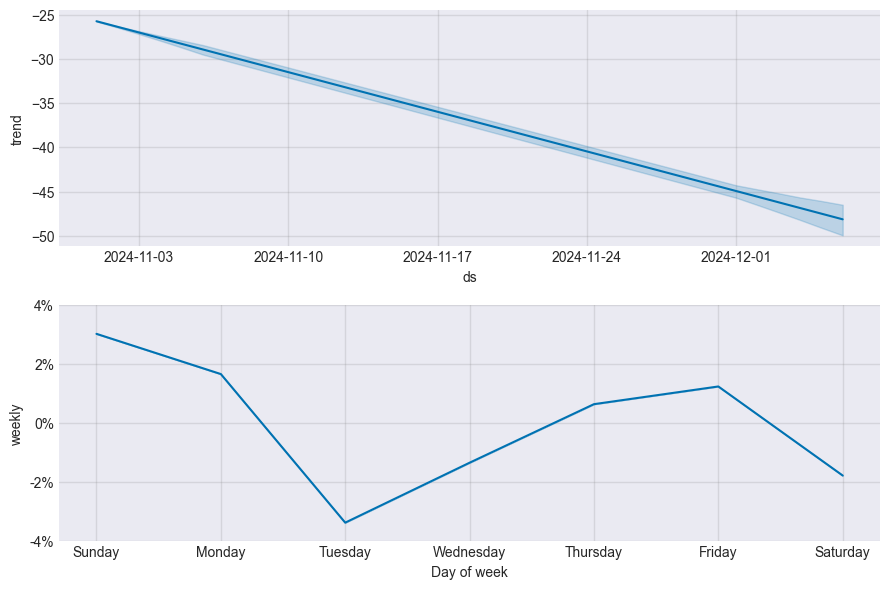

In [76]:
fig = model.plot_components(serv_test_fcst)
plt.show()

## Proyección

In [77]:
proyeccion = model.make_future_dataframe(periods=362, freq='D', include_history=False)
forecast = model.predict(proyeccion)

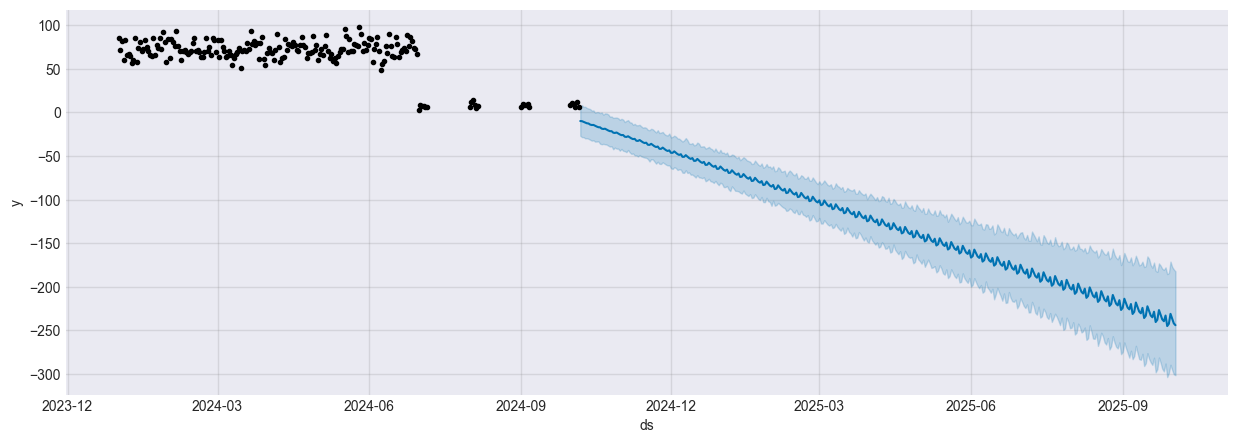

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
fig = model.plot(forecast, ax=ax)       
plt.show()  

In [79]:
forecast_test = forecast[forecast['ds'].isin(serv_test_fcst['ds'])][['ds', 'yhat']]

evaluacion = pd.merge(test_prophet, forecast_test, on='ds', how='left')

mae = mean_absolute_error(evaluacion['y'], evaluacion['yhat'])
mape = mean_absolute_percentage_error(evaluacion['y'], evaluacion['yhat'])

print(f"MAE: {mae:.0f}")
print(f"MAPE: {mape:.2%}")

MAE: 47
MAPE: 533.78%
